# 🎯 Özel Benchmark — Lojistik Alan Testi

**Senaryo:** Türkçe lojistik ve tedarik zinciri sorularını doğru yanıtlayabilen bir asistan

### Ödev Kriterleri
| Kriter | Hedef | Bu Notebook |
|--------|-------|-------------|
| Soru sayısı | ≥ 100 | 120 soru |
| Test edilen model | ≥ 5 | 6 model |
| Elle yazılmış soru | ≥ 10 | 15 soru |
| Eğitim dışı veri | %5-10 | Holdout split |

### Akış
1. Senaryo tanımı ve eğitim dışı veri ayırma
2. Elle 15 çoktan seçmeli soru yazma
3. GPT-4o mini ile sentetik soru üretimi (105 soru)
4. Benchmark'ı HuggingFace'e yayınlama
5. 6 farklı modeli test etme
6. Karşılaştırma + model kartı güncelleme

---


## 0. Kurulum

In [1]:
%%capture
!pip install unsloth
!pip uninstall -y torchcodec 2>/dev/null
!pip install -q datasets huggingface_hub pandas sentence-transformers openai

In [2]:
import os, time, json, gc, random
import torch
import pandas as pd

# ===== HuggingFace =====
try:
    from google.colab import userdata
    HF_TOKEN = userdata.get('HF_TOKEN')
    OPENAI_KEY = userdata.get('OPENAI_API_KEY')
except:
    HF_TOKEN = input("HuggingFace token: ")
    OPENAI_KEY = input("OpenAI API key: ")

os.environ["HF_TOKEN"] = HF_TOKEN
os.environ["OPENAI_API_KEY"] = OPENAI_KEY
from huggingface_hub import login, HfApi
login(token=HF_TOKEN)

# ===== Ayarlar =====
HF_USERNAME    = "cihatyldz"
LORA_REPO      = f"{HF_USERNAME}/lojistik-lora-adapter"
DATASET_REPO   = f"{HF_USERNAME}/lojistik-soru-cevap"
BENCHMARK_REPO = f"{HF_USERNAME}/lojistik-benchmark"

random.seed(42)
print("✓ Kurulum tamam")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


✓ Kurulum tamam


---
## 1. Senaryo Tanımı ve Eğitim Dışı Veri Ayırma

**Senaryo:** Model, lojistik profesyonellerinin ve öğrencilerinin tedarik zinciri, taşımacılık, depolama ve dağıtım konularındaki sorularını doğru yanıtlamalı.

**Ölçülecek yetenek:** Lojistik terminolojisi ve kavramlarına dair bilgi doğruluğu.

**Format:** Çoktan seçmeli (5 seçenek) — otomatik ve tarafsız puanlama için.

Önce fine-tune eğitiminde kullanılan veri setinden **%10'luk bir dilimi** ayırıyoruz. Bu dilim benchmark sorularının üretiminde kaynak olarak kullanılacak ve model bu veriyi eğitimde görmemiş olacak.


In [3]:
from datasets import load_dataset

# Eğitim veri setini yükle
try:
    ds = load_dataset(DATASET_REPO, split="train")
    print(f"Veri seti yüklendi: {len(ds)} örnek")

    # QA çiftlerini çıkar
    all_qa = []
    for row in ds:
        msgs = row["train"]
        if len(msgs) >= 2:
            all_qa.append({
                "question": msgs[0]["content"],
                "answer": msgs[1]["content"]
            })

    # %10 holdout — eğitimde KULLANILMAYACAK dilim
    random.shuffle(all_qa)
    holdout_size = max(int(len(all_qa) * 0.10), 20)
    holdout_qa = all_qa[:holdout_size]
    train_qa   = all_qa[holdout_size:]

    print(f"\nEğitim dilimi : {len(train_qa)} örnek (%{len(train_qa)/len(all_qa)*100:.0f})")
    print(f"Holdout dilimi: {len(holdout_qa)} örnek (%{len(holdout_qa)/len(all_qa)*100:.0f})")
    print(f"\nHoldout örnek soru: {holdout_qa[0]['question']}")

    # Holdout'u kaydet
    with open("holdout.jsonl", "w", encoding="utf-8") as f:
        for qa in holdout_qa:
            f.write(json.dumps(qa, ensure_ascii=False) + "\n")

except Exception as e:
    print(f"⚠ Veri seti yüklenemedi: {e}")
    print("Holdout olmadan devam ediliyor — benchmark tamamen yeni sorulardan oluşacak.")
    holdout_qa = []

⚠ Veri seti yüklenemedi: list_() takes at least 1 positional argument (0 given)
Holdout olmadan devam ediliyor — benchmark tamamen yeni sorulardan oluşacak.


---
## 2. Elle Yazılmış Sorular (15 adet)

Ödev kriteri: **en az 10 soru elle ve iyi düşünülmüş şekilde** hazırlanmalı.

Bu sorular lojistik sektöründeki pratik deneyime dayanarak yazılmıştır. Her soru:
- Tek bir net doğru cevaba sahip
- Çeldiricileri makul (rastgele değil)
- Farklı lojistik alt alanlarını kapsıyor


In [4]:
# ============================================
# ELLE YAZILMIŞ 15 ÇOKTAN SEÇMELİ SORU
# ============================================

elle_yazilan = [
    {
        "soru": "Bir dağıtım merkezinden 40 müşteriye teslimat yapılacaktır. Araç kapasitesi ve zaman penceresi kısıtları vardır. Bu problem hangi optimizasyon sınıfına girer?",
        "secenekler": [
            "Atama problemi (Assignment Problem)",
            "Kapasiteli Araç Rotalama Problemi (CVRP with Time Windows)",
            "Doğrusal programlama",
            "Minimum yayılan ağaç problemi",
            "Kritik yol yöntemi (CPM)"
        ],
        "cevap": 1,
        "aciklama": "Kapasite + zaman penceresi kısıtlı rotalama = CVRPTW"
    },
    {
        "soru": "Bir perakendeci, tedarikçisinden gelen siparişlerin %92'sini zamanında ancak %88'ini eksiksiz teslim aldığını raporluyor. Bu tedarikçinin OTIF skoru yaklaşık kaçtır?",
        "secenekler": ["%92", "%90", "%88", "%81", "%96"],
        "cevap": 3,
        "aciklama": "OTIF = On Time × In Full ≈ 0.92 × 0.88 ≈ 0.81"
    },
    {
        "soru": "FOB (Free On Board) teslim şeklinde risk, satıcıdan alıcıya hangi noktada geçer?",
        "secenekler": [
            "Satıcının deposundan çıkışta",
            "Mal yükleme limanında gemiye yüklendiğinde",
            "Varış limanına ulaştığında",
            "Alıcının deposuna teslim edildiğinde",
            "Gümrük beyannamesi düzenlendiğinde"
        ],
        "cevap": 1,
        "aciklama": "FOB'da risk mal gemiye yüklendiğinde alıcıya geçer"
    },
    {
        "soru": "Yıllık talebi 10.000 birim, sipariş başına maliyeti 200 TL ve birim başına yıllık stok tutma maliyeti 4 TL olan bir ürünün EOQ değeri kaçtır?",
        "secenekler": ["500 birim", "1.000 birim", "1.414 birim", "2.000 birim", "707 birim"],
        "cevap": 1,
        "aciklama": "EOQ = √(2×10000×200/4) = √1.000.000 = 1000"
    },
    {
        "soru": "Cross-docking uygulamasının BAŞARILI olması için aşağıdakilerden hangisi en kritik ön koşuldur?",
        "secenekler": [
            "Geniş depolama alanı bulunması",
            "Yüksek güvenlik stoku tutulması",
            "Gelen ve giden sevkiyatların zamanlamasının senkronize olması",
            "Ürünlerin uzun raf ömrüne sahip olması",
            "Manuel sipariş toplama sisteminin kullanılması"
        ],
        "cevap": 2,
        "aciklama": "Cross-docking stok tutmadığı için zamanlama senkronizasyonu kritiktir"
    },
    {
        "soru": "Bir tedarik zincirinde perakendeci talebi %10 dalgalanırken üretici seviyesinde bu dalgalanma %60'a çıkmaktadır. Bu durum hangi olguyla açıklanır?",
        "secenekler": [
            "Pareto ilkesi",
            "Bullwhip (kırbaç) etkisi",
            "Ölçek ekonomisi",
            "Little yasası",
            "Ters lojistik etkisi"
        ],
        "cevap": 1,
        "aciklama": "Talep dalgalanmasının zincir yukarı büyümesi = bullwhip etkisi"
    },
    {
        "soru": "ABC analizinde 'A' grubu stok kalemleri için genellikle hangi yönetim yaklaşımı benimsenir?",
        "secenekler": [
            "Yüksek güvenlik stoku, seyrek sayım",
            "Sıkı kontrol, sık sayım, düşük güvenlik stoku",
            "Kontrolsüz, otomatik yeniden sipariş",
            "Yılda bir kez sayım, toplu sipariş",
            "Tedarikçi yönetimli envanter zorunlu"
        ],
        "cevap": 1,
        "aciklama": "A grubu yüksek değerli olduğu için sıkı kontrol gerektirir"
    },
    {
        "soru": "40 feet'lik 3 konteyner ve 20 feet'lik 4 konteyner taşıyan bir gemi kaç TEU yük taşımaktadır?",
        "secenekler": ["7 TEU", "10 TEU", "12 TEU", "14 TEU", "8 TEU"],
        "cevap": 1,
        "aciklama": "(3 × 2 TEU) + (4 × 1 TEU) = 6 + 4 = 10 TEU"
    },
    {
        "soru": "Talep standart sapması 50 birim, tedarik süresi 4 hafta ve hedef hizmet seviyesi %95 (Z=1.65) olan bir ürünün güvenlik stoku yaklaşık kaçtır?",
        "secenekler": ["82 birim", "165 birim", "200 birim", "330 birim", "103 birim"],
        "cevap": 1,
        "aciklama": "SS = 1.65 × 50 × √4 = 1.65 × 50 × 2 = 165"
    },
    {
        "soru": "Bir lojistik şirketi, birden fazla müşterinin küçük hacimli yüklerini aynı araçta birleştirerek taşıyor. Bu taşımacılık türü nedir?",
        "secenekler": [
            "FTL (Full Truck Load)",
            "LTL (Less Than Truck Load)",
            "FCL (Full Container Load)",
            "Milk run",
            "Bulk taşımacılık"
        ],
        "cevap": 1,
        "aciklama": "Farklı göndericilerin yüklerinin konsolidasyonu = LTL"
    },
    {
        "soru": "Depoda sipariş toplama (picking) verimliliğini artırmak için ürünlerin hareket hızına göre raflara yerleştirilmesi hangi tekniktir?",
        "secenekler": [
            "Cross-docking",
            "Slotting (raf optimizasyonu)",
            "Kitting",
            "Wave picking",
            "Put-to-light"
        ],
        "cevap": 1,
        "aciklama": "Ürünlerin hareket hızına göre konumlandırılması = slotting"
    },
    {
        "soru": "Aşağıdakilerden hangisi tersine lojistik (reverse logistics) kapsamına GİRMEZ?",
        "secenekler": [
            "Müşteri iadelerinin işlenmesi",
            "Garanti kapsamındaki onarımlar",
            "Ambalaj malzemelerinin geri toplanması",
            "Tedarikçiden hammadde satın alınması",
            "Ömrünü tamamlamış ürünlerin geri dönüşümü"
        ],
        "cevap": 3,
        "aciklama": "Hammadde satın alma ileri yönlü lojistiktir, tersine değil"
    },
    {
        "soru": "4PL hizmet sağlayıcısını 3PL'den ayıran temel özellik nedir?",
        "secenekler": [
            "Sadece depolama hizmeti vermesi",
            "Kendi araç filosuna sahip olması",
            "Tüm tedarik zincirini stratejik düzeyde yönetip birden fazla 3PL'yi koordine etmesi",
            "Sadece uluslararası taşımacılık yapması",
            "Yalnızca gümrük işlemleriyle ilgilenmesi"
        ],
        "cevap": 2,
        "aciklama": "4PL stratejik entegratördür, birden fazla 3PL'yi yönetir"
    },
    {
        "soru": "Bir kargo firması yükleri önce merkezi bir aktarma tesisine toplayıp oradan hedef şehirlere dağıtmaktadır. Bu ağ yapısı nedir?",
        "secenekler": [
            "Point-to-point (noktadan noktaya)",
            "Hub-and-spoke (merkez-uydu)",
            "Milk run",
            "Direct shipping",
            "Cross-dock ağı"
        ],
        "cevap": 1,
        "aciklama": "Merkezi toplama + dağıtım = hub-and-spoke"
    },
    {
        "soru": "Son mil teslimatın toplam lojistik maliyeti içindeki payı neden diğer aşamalardan yüksektir?",
        "secenekler": [
            "Yakıt fiyatlarının bu aşamada daha pahalı olması",
            "Bireysel adreslere dağılma, düşük araç doluluğu ve başarısız teslimat denemeleri",
            "Uluslararası gümrük vergileri",
            "Deniz taşımacılığı ücretlerinin yüksekliği",
            "Depolama maliyetlerinin bu aşamada oluşması"
        ],
        "cevap": 1,
        "aciklama": "Dağınık teslimat noktaları + düşük konsolidasyon = yüksek birim maliyet"
    },
]

print(f"✓ {len(elle_yazilan)} elle yazılmış soru hazır")
print(f"\nÖrnek soru:")
q = elle_yazilan[1]
print(f"  {q['soru']}")
harfler = ['A','B','C','D','E']
for i, s in enumerate(q['secenekler']):
    isaret = " ✓" if i == q['cevap'] else ""
    print(f"    {harfler[i]}: {s}{isaret}")
print(f"  Açıklama: {q['aciklama']}")

✓ 15 elle yazılmış soru hazır

Örnek soru:
  Bir perakendeci, tedarikçisinden gelen siparişlerin %92'sini zamanında ancak %88'ini eksiksiz teslim aldığını raporluyor. Bu tedarikçinin OTIF skoru yaklaşık kaçtır?
    A: %92
    B: %90
    C: %88
    D: %81 ✓
    E: %96
  Açıklama: OTIF = On Time × In Full ≈ 0.92 × 0.88 ≈ 0.81


---
## 3. Sentetik Soru Üretimi

Elle yazılan 15 soruyu şablon olarak kullanıp, holdout verisinden de yararlanarak 105 ek soru üretiyoruz.  
**Toplam hedef: 120 soru**


In [5]:
from openai import OpenAI

client = OpenAI(api_key=OPENAI_KEY)
harfler = ['A', 'B', 'C', 'D', 'E']

# Elle yazılan sorulardan şablon oluştur
ornek_metin = ""
for q in elle_yazilan[:4]:
    ornek_metin += f"SORU: {q['soru']}\n"
    for i, s in enumerate(q['secenekler']):
        ornek_metin += f"{harfler[i]}: {s}\n"
    ornek_metin += f"DOGRU: {harfler[q['cevap']]}\n\n"

# Holdout verisinden konu ipuçları
holdout_konular = ""
if holdout_qa:
    for qa in holdout_qa[:10]:
        holdout_konular += f"- {qa['question']}\n"

konu_gruplari = [
    ("Depo ve envanter yönetimi", "WMS, slotting, picking stratejileri, FIFO/LIFO, stok devir hızı, envanter doğruluğu, döngü sayımı"),
    ("Taşımacılık ve rotalama", "VRP varyantları, araç doluluk oranı, intermodal taşıma, yük konsolidasyonu, filo yönetimi, telematik"),
    ("Dış ticaret ve gümrük", "Incoterms 2020, konşimento türleri, akreditif, gümrük rejimleri, menşe belgesi, ATR/EUR.1"),
    ("Tedarik zinciri planlama", "S&OP, MRP, talep tahmini metrikleri (MAPE, bias), kapasite planlama, tedarikçi seçimi"),
    ("Lojistik performans ve maliyet", "KPI'lar, birim maliyet analizi, lojistik maliyet kalemleri, hizmet seviyesi anlaşmaları, benchmark oranları"),
    ("E-ticaret ve son mil", "sipariş karşılama modelleri, iade yönetimi, teslimat slot planlama, dark store, mikro dağıtım merkezi"),
    ("Yalın ve sürdürülebilir lojistik", "muda türleri, kaizen, yeşil lojistik, karbon hesaplama, döngüsel tedarik zinciri"),
]

sentetik_sorular = []
soru_hedefi_per_grup = 15

for grup_adi, konular in konu_gruplari:
    prompt = f"""Türkçe lojistik alanında çoktan seçmeli sınav soruları hazırla.

Konu grubu: {grup_adi}
Alt konular: {konular}

KURALLAR:
- Her sorunun 5 seçeneği olsun (A, B, C, D, E)
- Tek bir net doğru cevap olsun
- Çeldiriciler makul ve alanla ilgili olsun (rastgele olmasın)
- Sorular hem kavramsal hem hesaplama içerebilir
- Zorluk seviyesi: lisans/sektör profesyoneli düzeyi

FORMAT (kesinlikle buna uy):
SORU: [soru metni]
A: [seçenek]
B: [seçenek]
C: [seçenek]
D: [seçenek]
E: [seçenek]
DOGRU: [tek harf]

Örnekler:
{ornek_metin}

Şimdi bu formatta {soru_hedefi_per_grup} adet YENİ soru üret. Sadece belirtilen formatta yaz."""

    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": "Sen lojistik alanında uzman bir sınav sorusu hazırlayıcısısın. Sadece istenen formatta çıktı ver."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.8,
            max_tokens=4000,
        )
        text = response.choices[0].message.content

        # Parse
        bloklar = text.split("SORU:")
        grup_sorulari = []
        for blok in bloklar[1:]:
            satirlar = [s.strip() for s in blok.strip().split("\n") if s.strip()]
            if len(satirlar) < 7:
                continue
            soru_metni = satirlar[0].strip()
            secenekler = []
            dogru_harf = None
            for satir in satirlar[1:]:
                if satir.startswith("DOGRU:"):
                    dogru_harf = satir.replace("DOGRU:", "").strip().upper()[:1]
                elif len(satir) > 2 and satir[0] in harfler and satir[1] in [":", ")"]:
                    secenekler.append(satir[2:].strip())
            if len(secenekler) == 5 and dogru_harf in harfler and len(soru_metni) > 15:
                grup_sorulari.append({
                    "soru": soru_metni,
                    "secenekler": secenekler,
                    "cevap": harfler.index(dogru_harf),
                    "kategori": grup_adi,
                })
        sentetik_sorular.extend(grup_sorulari)
        print(f"  {grup_adi:<35} → {len(grup_sorulari)} soru")

    except Exception as e:
        print(f"  {grup_adi:<35} → HATA: {e}")

print(f"\n✓ Toplam {len(sentetik_sorular)} sentetik soru üretildi")

  Depo ve envanter yönetimi           → 15 soru
  Taşımacılık ve rotalama             → 14 soru
  Dış ticaret ve gümrük               → 14 soru
  Tedarik zinciri planlama            → 15 soru
  Lojistik performans ve maliyet      → 15 soru
  E-ticaret ve son mil                → 15 soru
  Yalın ve sürdürülebilir lojistik    → 14 soru

✓ Toplam 102 sentetik soru üretildi


### 3.1 Benchmark'ı Birleştir ve Doğrula

In [6]:
# Elle yazılanlara kategori ekle
for q in elle_yazilan:
    q["kategori"] = "Elle Yazılmış"
    q.pop("aciklama", None)

# Birleştir
benchmark = elle_yazilan + sentetik_sorular

# Tekrar eden soruları temizle
gorulen = set()
temiz_benchmark = []
for q in benchmark:
    anahtar = q["soru"].lower().strip()[:80]
    if anahtar not in gorulen:
        gorulen.add(anahtar)
        temiz_benchmark.append(q)

benchmark = temiz_benchmark

# Doğrulama
hatali = 0
for i, q in enumerate(benchmark):
    if len(q["secenekler"]) != 5:
        print(f"⚠ Soru {i}: {len(q['secenekler'])} seçenek var (5 olmalı)")
        hatali += 1
    if not (0 <= q["cevap"] < 5):
        print(f"⚠ Soru {i}: geçersiz cevap indeksi {q['cevap']}")
        hatali += 1

print(f"{'='*55}")
print(f"  BENCHMARK ÖZETİ")
print(f"{'='*55}")
print(f"  Toplam soru      : {len(benchmark)}")
print(f"  Elle yazılmış    : {sum(1 for q in benchmark if q['kategori']=='Elle Yazılmış')}")
print(f"  Sentetik         : {sum(1 for q in benchmark if q['kategori']!='Elle Yazılmış')}")
print(f"  Hatalı soru      : {hatali}")
print(f"  Rastgele başarı  : %20 (5 seçenek)")
print(f"{'='*55}")

print(f"\n  Kategori dağılımı:")
from collections import Counter
for kat, adet in Counter(q["kategori"] for q in benchmark).most_common():
    print(f"    {kat:<38} {adet:>3} soru")

# Kriter kontrolü
print(f"\n  Ödev kriterleri:")
print(f"    ≥100 soru        : {'✓' if len(benchmark) >= 100 else '✗'} ({len(benchmark)})")
elle_sayi = sum(1 for q in benchmark if q['kategori']=='Elle Yazılmış')
print(f"    ≥10 elle yazılmış: {'✓' if elle_sayi >= 10 else '✗'} ({elle_sayi})")

  BENCHMARK ÖZETİ
  Toplam soru      : 116
  Elle yazılmış    : 15
  Sentetik         : 101
  Hatalı soru      : 0
  Rastgele başarı  : %20 (5 seçenek)

  Kategori dağılımı:
    Elle Yazılmış                           15 soru
    Depo ve envanter yönetimi               15 soru
    Tedarik zinciri planlama                15 soru
    Lojistik performans ve maliyet          15 soru
    E-ticaret ve son mil                    15 soru
    Taşımacılık ve rotalama                 14 soru
    Dış ticaret ve gümrük                   14 soru
    Yalın ve sürdürülebilir lojistik        13 soru

  Ödev kriterleri:
    ≥100 soru        : ✓ (116)
    ≥10 elle yazılmış: ✓ (15)


---
## 4. Benchmark'ı HuggingFace'e Yayınla

Benchmark ayrı bir veri seti olarak yayınlanıyor (açık benchmark).


In [7]:
from datasets import Dataset

# Dataset formatına dönüştür
bench_dict = {
    "soru": [q["soru"] for q in benchmark],
    "secenekler": [q["secenekler"] for q in benchmark],
    "cevap": [q["cevap"] for q in benchmark],
    "kategori": [q["kategori"] for q in benchmark],
}
bench_ds = Dataset.from_dict(bench_dict)

# Yerel yedek
with open("lojistik_benchmark.jsonl", "w", encoding="utf-8") as f:
    for q in benchmark:
        f.write(json.dumps(q, ensure_ascii=False) + "\n")

# HF'ye yükle
bench_ds.push_to_hub(BENCHMARK_REPO, private=False)
print(f"✓ Benchmark yüklendi: https://huggingface.co/datasets/{BENCHMARK_REPO}")

# Dataset kartı
bench_card = f"""---
tags: [benchmark, logistics, turkish, multiple-choice, supply-chain]
language: tr
license: mit
size_categories: [n<1K]
---

# Lojistik Benchmark — Türkçe Çoktan Seçmeli Test Seti

Türkçe lojistik ve tedarik zinciri alanında dil modellerini değerlendirmek için hazırlanmış özel benchmark.

## İstatistikler

| Özellik | Değer |
|---------|-------|
| Toplam soru | {len(benchmark)} |
| Elle yazılmış | {elle_sayi} |
| Sentetik (GPT-4o mini) | {len(benchmark) - elle_sayi} |
| Seçenek sayısı | 5 (A-E) |
| Rastgele başarı tabanı | %20 |

## Kategoriler

| Kategori | Soru Sayısı |
|----------|-------------|
"""
for kat, adet in Counter(q["kategori"] for q in benchmark).most_common():
    bench_card += f"| {kat} | {adet} |\n"

bench_card += f"""

## Format

```python
{{
  "soru": "Bir dağıtım merkezinden 40 müşteriye teslimat yapılacaktır...",
  "secenekler": ["Atama problemi", "CVRPTW", "Doğrusal programlama", "...", "..."],
  "cevap": 1,          # doğru seçeneğin indeksi (0-4)
  "kategori": "Elle Yazılmış"
}}
```

## Kullanım

```python
from datasets import load_dataset
bench = load_dataset("{BENCHMARK_REPO}", split="train")

harfler = ['A','B','C','D','E']
row = bench[0]
print(row["soru"])
for i, s in enumerate(row["secenekler"]):
    print(f"{{harfler[i]}}: {{s}}")
print("Doğru:", harfler[row["cevap"]])
```

## Metodoloji

- **Elle yazılan sorular:** Lojistik sektöründeki pratik deneyime dayanarak hazırlanmış, çeldiricileri makul ve tek net doğru cevaba sahip sorular.
- **Sentetik sorular:** Elle yazılan sorular şablon olarak verilerek GPT-4o mini ile üretilmiş, format doğrulamasından geçirilmiştir.
- **Eğitim verisi ayrımı:** Fine-tune eğitiminde kullanılan veri setinden %10'luk bir dilim kenara ayrılmış, benchmark bu dilimden ve yeni sorulardan oluşturulmuştur.

## Yazar

Cihat Yıldız — [{HF_USERNAME}](https://huggingface.co/{HF_USERNAME})
"""

with open("bench_readme.md", "w", encoding="utf-8") as f:
    f.write(bench_card)

api = HfApi()
api.upload_file(
    path_or_fileobj="bench_readme.md",
    path_in_repo="README.md",
    repo_id=BENCHMARK_REPO,
    repo_type="dataset",
)
print(f"✓ Dataset kartı yüklendi")

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              : 100%|##########| 19.7kB / 19.7kB            

README.md:   0%|          | 0.00/2.04k [00:00<?, ?B/s]

✓ Benchmark yüklendi: https://huggingface.co/datasets/cihatyldz/lojistik-benchmark
✓ Dataset kartı yüklendi


---
## 5. Test Fonksiyonu

Puanlama yöntemi: **Accuracy** (doğru cevap / toplam soru)

Cevap ayıklama 3 aşamalı:
1. Doğrudan harf eşleşmesi
2. Harf + ayraç (A:, A), A- vb.)
3. Anlamsal benzerlik (fallback)


In [8]:
from sentence_transformers import SentenceTransformer

anlamsal_model = SentenceTransformer("paraphrase-multilingual-mpnet-base-v2")
harfler = ['A', 'B', 'C', 'D', 'E']


def cevap_dogru_mu(dogru_index, verilen_cevap, secenekler):
    """3 aşamalı cevap kontrolü."""
    dogru_harf = harfler[dogru_index]
    verilen = verilen_cevap.upper().strip()

    if not verilen:
        return False
    if dogru_harf == verilen:
        return True
    if len(verilen) > 1 and verilen[1] in [" ", ":", ")", "=", "-", ".", ","]:
        return dogru_harf == verilen[0]
    if len(verilen) == 1 and verilen in harfler:
        return dogru_harf == verilen

    # Anlamsal benzerlik
    try:
        enc_c = anlamsal_model.encode([verilen_cevap])
        enc_s = anlamsal_model.encode(secenekler)
        benzerlikler = anlamsal_model.similarity(enc_c, enc_s).tolist()[0]
        return benzerlikler.index(max(benzerlikler)) == dogru_index
    except:
        return False


def ilerleme_cubugu(guncel, toplam, uzunluk=30):
    oran = guncel / toplam
    blok = int(uzunluk * oran)
    return f"[{'#'*blok}{'-'*(uzunluk-blok)}] {oran*100:.1f}%"


def benchmark_calistir(model_obj, tokenizer_obj, model_adi):
    """Benchmark testini çalıştır."""
    baslangic = time.time()
    dogru_sayisi = 0
    kategori_sonuc = {}
    cevaplar = []

    for i, q in enumerate(benchmark):
        soru_metni = q["soru"] + "\n"
        for j, s in enumerate(q["secenekler"]):
            soru_metni += f"{harfler[j]}: {s}\n"

        prompt = ("Sana soru ve seçenekleri veriyorum. Sadece hangi seçeneğin "
                  "sorunun doğru cevabı olduğunu yaz. Örneğin 'A' veya 'B' gibi. "
                  "Lütfen herhangi bir açıklama yapma!\nSoru: " + soru_metni)

        messages = [{"role": "user", "content": prompt}]
        inputs = tokenizer_obj.apply_chat_template(
            messages, tokenize=True, add_generation_prompt=True,
            return_tensors="pt"
        ).to("cuda")

        with torch.no_grad():
            outputs = model_obj.generate(
                input_ids=inputs,
                max_new_tokens=42,
                temperature=0.01,
                do_sample=True,
                use_cache=True,
            )

        cevap = tokenizer_obj.decode(
            outputs[0][inputs.shape[1]:], skip_special_tokens=True
        ).strip()

        if "</think>" in cevap:
            cevap = cevap.split("</think>")[-1].strip()

        kat = q["kategori"]
        if kat not in kategori_sonuc:
            kategori_sonuc[kat] = {"dogru": 0, "toplam": 0}
        kategori_sonuc[kat]["toplam"] += 1

        dogru_mu = cevap_dogru_mu(q["cevap"], cevap, q["secenekler"])
        if dogru_mu:
            dogru_sayisi += 1
            kategori_sonuc[kat]["dogru"] += 1

        cevaplar.append({"index": i, "verilen": cevap[:50], "dogru": dogru_mu})

        gecen = time.time() - baslangic
        print(f"\r  {i+1}/{len(benchmark)} | Doğru: {dogru_sayisi} | "
              f"Başarı: %{dogru_sayisi/(i+1)*100:.1f} | "
              f"{gecen:.0f}s {ilerleme_cubugu(i+1, len(benchmark))}", end="")

    sure = round(time.time() - baslangic, 1)
    basari = round(dogru_sayisi / len(benchmark) * 100, 2)

    print(f"\n  ✓ {model_adi}: %{basari} ({dogru_sayisi}/{len(benchmark)}) — {sure}s\n")

    return {
        "model": model_adi,
        "basari": basari,
        "dogru": dogru_sayisi,
        "toplam": len(benchmark),
        "sure": sure,
        "kategori_sonuc": kategori_sonuc,
        "cevaplar": cevaplar,
    }

print("✓ Test fonksiyonu hazır")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Test fonksiyonu hazır


---
## 6. Modelleri Test Et (6 Model)

Ödev kriteri: **en az 5 farklı model**

| # | Model | Tip |
|---|-------|-----|
| 1 | `cihatyldz/lojistik-lora-adapter` | Kendi fine-tuned modelim |
| 2 | `Qwen3-1.7B` | Base model (karşılaştırma) |
| 3 | `Qwen2.5-1.5B-Instruct` | Farklı nesil Qwen |
| 4 | `Llama-3.2-3B-Instruct` | Meta |
| 5 | `gemma-3-1b-it` | Google |
| 6 | `SmolLM2-1.7B-Instruct` | Huggingface |

> Bellek yönetimi: her model test edildikten sonra GPU belleği temizlenir.


In [9]:
from huggingface_hub import list_repo_files, hf_hub_download
from safetensors import safe_open

files = list_repo_files(LORA_REPO)
print("Repo içeriği:", files)

# model.safetensors'ın içinde ne var?
path = hf_hub_download(LORA_REPO, "model.safetensors")
with safe_open(path, framework="pt") as f:
    keys = list(f.keys())

print(f"\nToplam tensor: {len(keys)}")
print("İlk 5 key:", keys[:5])

lora_var = any("lora_A" in k or "lora_B" in k for k in keys)
print(f"\nLoRA ağırlıkları içeriyor mu? {'EVET' if lora_var else 'HAYIR (tam model)'}")

Repo içeriği: ['.gitattributes', 'README.md', 'chat_template.jinja', 'config.json', 'generation_config.json', 'model.safetensors', 'tokenizer.json', 'tokenizer_config.json']

Toplam tensor: 310
İlk 5 key: ['model.embed_tokens.weight', 'model.layers.0.input_layernorm.weight', 'model.layers.0.mlp.down_proj.weight', 'model.layers.0.mlp.gate_proj.weight', 'model.layers.0.mlp.up_proj.weight']

LoRA ağırlıkları içeriyor mu? HAYIR (tam model)


In [10]:
import json, torch
from huggingface_hub import hf_hub_download, HfApi
from safetensors import safe_open

api = HfApi()

# 1) Yüklenen modelin boyutlarını kontrol et
path = hf_hub_download(LORA_REPO, "model.safetensors")
with safe_open(path, framework="pt") as f:
    emb = f.get_slice("model.embed_tokens.weight")
    vocab_size, hidden = emb.get_shape()
    katman_sayisi = len({
        k.split(".")[2] for k in f.keys() if k.startswith("model.layers.")
    })
print(f"Yüklenen model → vocab: {vocab_size}, hidden: {hidden}, katman: {katman_sayisi}")

# 2) Base model config'ini al (quantize edilmemiş sürümden)
cfg_path = hf_hub_download("Qwen/Qwen3-1.7B", "config.json")
cfg = json.load(open(cfg_path))
print(f"Base config    → vocab: {cfg['vocab_size']}, hidden: {cfg['hidden_size']}, katman: {cfg['num_hidden_layers']}")

# 3) Uyuşmazlık varsa düzelt + quantization ayarını temizle
cfg.pop("quantization_config", None)
cfg["vocab_size"] = vocab_size
cfg["hidden_size"] = hidden
cfg["num_hidden_layers"] = katman_sayisi
cfg["torch_dtype"] = "bfloat16"

with open("config.json", "w") as f:
    json.dump(cfg, f, indent=2)

# 4) Repo'ya yükle
api.upload_file(
    path_or_fileobj="config.json",
    path_in_repo="config.json",
    repo_id=LORA_REPO,
)

# 5) generation_config da ekle (opsiyonel ama faydalı)
try:
    gen_path = hf_hub_download("Qwen/Qwen3-1.7B", "generation_config.json")
    api.upload_file(
        path_or_fileobj=gen_path,
        path_in_repo="generation_config.json",
        repo_id=LORA_REPO,
    )
except Exception as e:
    print(f"generation_config atlandı: {e}")

from huggingface_hub import list_repo_files
print(f"\n✓ Repo şimdi: {list_repo_files(LORA_REPO)}")

Yüklenen model → vocab: 151936, hidden: 2048, katman: 28
Base config    → vocab: 151936, hidden: 2048, katman: 28


No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.



✓ Repo şimdi: ['.gitattributes', 'README.md', 'chat_template.jinja', 'config.json', 'generation_config.json', 'model.safetensors', 'tokenizer.json', 'tokenizer_config.json']


In [11]:
from unsloth import FastLanguageModel
from unsloth.chat_templates import get_chat_template

# chat_template=None → modelin kendi template'ini kullan (en güvenli)
TEST_EDILECEK_MODELLER = [
    (LORA_REPO,                                    None, "Fine-tuned (kendi modelim)"),
    ("unsloth/Qwen3-1.7B-unsloth-bnb-4bit",        None, "Base model"),
    ("unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit",     None, "Qwen 2.5"),
    ("unsloth/Llama-3.2-3B-Instruct-bnb-4bit",     None, "Meta Llama"),
    ("unsloth/gemma-3-1b-it-unsloth-bnb-4bit",     None, "Google Gemma"),
    ("unsloth/SmolLM2-1.7B-Instruct-bnb-4bit",     None, "HuggingFace SmolLM2"),
]

tum_sonuclar = []

for model_id, chat_tmpl, aciklama in TEST_EDILECEK_MODELLER:
    print(f"\n{'='*60}")
    print(f"  {aciklama}")
    print(f"  {model_id}")
    print(f"{'='*60}")

    m = tok = None
    try:
        m, tok = FastLanguageModel.from_pretrained(
            model_name=model_id,
            max_seq_length=2048,
            load_in_4bit=True,
        )

        # Template yoksa varsayılan ata, varsa dokunma
        if tok.chat_template is None:
            if chat_tmpl:
                tok = get_chat_template(tok, chat_template=chat_tmpl)
            else:
                print("  ⚠ Chat template yok, model atlanıyor")
                raise ValueError("chat_template bulunamadı")

        FastLanguageModel.for_inference(m)

        sonuc = benchmark_calistir(m, tok, model_id)
        sonuc["aciklama"] = aciklama
        tum_sonuclar.append(sonuc)

        # Her başarılı testten sonra kaydet — çökerse veri kaybolmasın
        with open("benchmark_ara_sonuc.json", "w", encoding="utf-8") as f:
            json.dump([{
                "model": s["model"], "aciklama": s["aciklama"],
                "basari": s["basari"], "dogru": s["dogru"],
                "toplam": s["toplam"], "sure": s["sure"],
                "kategori_sonuc": {k: dict(v) for k, v in s["kategori_sonuc"].items()},
            } for s in tum_sonuclar], f, ensure_ascii=False, indent=2)

    except Exception as e:
        print(f"\n  ⚠ Test edilemedi: {str(e)[:200]}")

    finally:
        try:
            del m, tok
        except:
            pass
        gc.collect()
        try:
            torch.cuda.empty_cache()
        except Exception:
            print("  ⚠ GPU context bozuk — runtime'ı yeniden başlatın")

print(f"\n{'='*60}")
print(f"  ✓ {len(tum_sonuclar)} model test edildi")
print(f"{'='*60}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/usr/local/lib/python3.12/dist-packages/unsloth/__init__.py:1432: UserWarning: WARNING: Unsloth should be imported before [transformers, peft] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


🦥 Unsloth Zoo will now patch everything to make training faster!

  Fine-tuned (kendi modelim)
  cihatyldz/lojistik-lora-adapter
==((====))==  Unsloth 2026.7.5: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=42) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_m

...

  113/116 | Doğru: 21 | Başarı: %18.6 | 196s [#############################-] 97.4%

Both `max_new_tokens` (=42) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  114/116 | Doğru: 21 | Başarı: %18.4 | 197s [#############################-] 98.3%

Both `max_new_tokens` (=42) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  116/116 | Doğru: 21 | Başarı: %18.1 | 201s [##############################] 100.0%
  ✓ unsloth/SmolLM2-1.7B-Instruct-bnb-4bit: %18.1 (21/116) — 201.1s


  ✓ 6 model test edildi


---
## 7. Sonuçlar ve Karşılaştırma


In [12]:
# Sırala
sirali = sorted(tum_sonuclar, key=lambda x: x["basari"], reverse=True)

print("\n" + "="*78)
print("  LOJİSTİK BENCHMARK SONUÇLARI".center(78))
print("="*78)
print(f"  {'#':<3} {'Model':<45} {'Başarı':>8} {'Doğru':>7} {'Süre':>8}")
print("-"*78)
for i, s in enumerate(sirali, 1):
    isaret = " ★" if s["model"] == LORA_REPO else "  "
    kisa_ad = s["model"].split("/")[-1][:42]
    print(f"  {i:<3}{isaret}{kisa_ad:<43} {s['basari']:>7.2f}% "
          f"{s['dogru']:>4}/{s['toplam']:<3} {s['sure']:>7.1f}s")
print("-"*78)
print(f"  Rastgele başarı tabanı: %20.00 (5 seçenek)")
print("="*78)

# Kategori bazlı karşılaştırma
tum_kategoriler = sorted({k for s in tum_sonuclar for k in s["kategori_sonuc"]})

print(f"\n\n  KATEGORİ BAZLI SONUÇLAR")
print("-"*78)
basliklar = [s["model"].split("/")[-1][:14] for s in sirali]
print(f"  {'Kategori':<32}" + "".join(f"{b:>15}" for b in basliklar[:3]))
print("-"*78)
for kat in tum_kategoriler:
    satir = f"  {kat[:30]:<32}"
    for s in sirali[:3]:
        k = s["kategori_sonuc"].get(kat, {"dogru": 0, "toplam": 1})
        pct = k["dogru"] / k["toplam"] * 100 if k["toplam"] else 0
        satir += f"{pct:>14.1f}%"
    print(satir)

# Sonuçları kaydet
kayit = []
for s in tum_sonuclar:
    kayit.append({
        "model": s["model"],
        "aciklama": s["aciklama"],
        "basari": s["basari"],
        "dogru": s["dogru"],
        "toplam": s["toplam"],
        "sure": s["sure"],
        "kategori_sonuc": {k: dict(v) for k, v in s["kategori_sonuc"].items()},
    })
with open("benchmark_sonuclari.json", "w", encoding="utf-8") as f:
    json.dump(kayit, f, ensure_ascii=False, indent=2)
print(f"\n✓ Sonuçlar benchmark_sonuclari.json'a kaydedildi")


                          LOJİSTİK BENCHMARK SONUÇLARI                        
  #   Model                                           Başarı   Doğru     Süre
------------------------------------------------------------------------------
  1    Llama-3.2-3B-Instruct-bnb-4bit                56.03%   65/116    22.5s
  2   ★lojistik-lora-adapter                         50.86%   59/116   178.0s
  3    gemma-3-1b-it-unsloth-bnb-4bit                50.00%   58/116   154.5s
  4    Qwen2.5-1.5B-Instruct-bnb-4bit                34.48%   40/116   113.8s
  5    Qwen3-1.7B-unsloth-bnb-4bit                   32.76%   38/116   268.8s
  6    SmolLM2-1.7B-Instruct-bnb-4bit                18.10%   21/116   201.1s
------------------------------------------------------------------------------
  Rastgele başarı tabanı: %20.00 (5 seçenek)


  KATEGORİ BAZLI SONUÇLAR
------------------------------------------------------------------------------
  Kategori                         Llama-3.2-3B-I lojistik-lora-

### 7.1 Görselleştirme

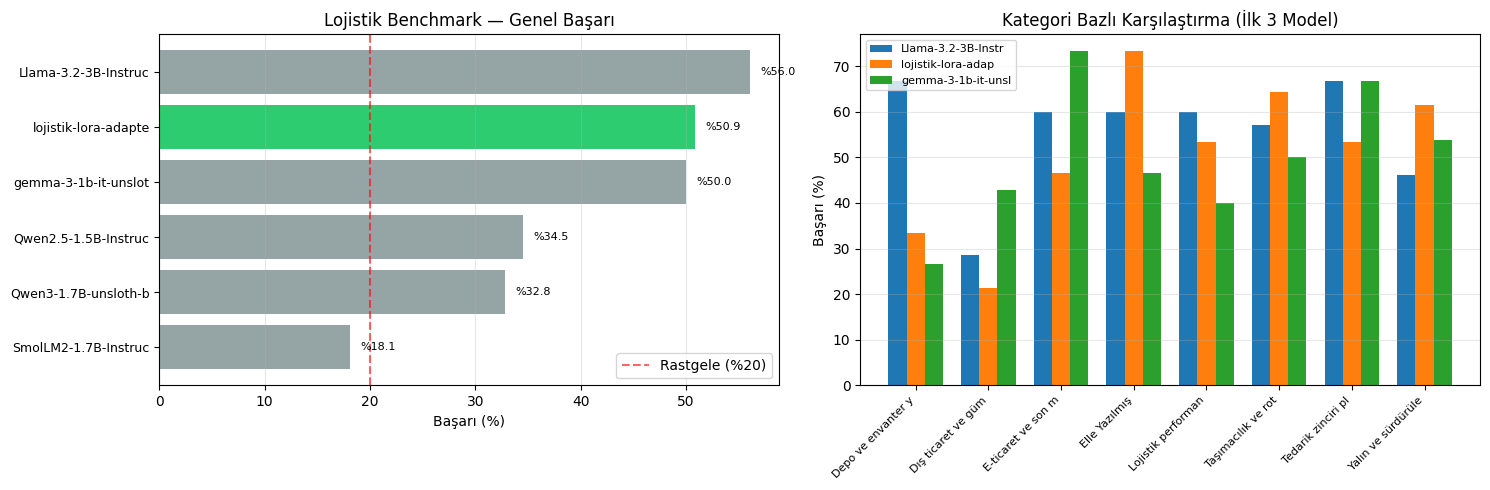

In [13]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Genel başarı
adlar = [s["model"].split("/")[-1][:20] for s in sirali]
skorlar = [s["basari"] for s in sirali]
renkler = ["#2ecc71" if s["model"] == LORA_REPO else "#95a5a6" for s in sirali]

ax1.barh(range(len(adlar)), skorlar, color=renkler)
ax1.set_yticks(range(len(adlar)))
ax1.set_yticklabels(adlar, fontsize=9)
ax1.invert_yaxis()
ax1.axvline(20, color="red", linestyle="--", alpha=0.6, label="Rastgele (%20)")
ax1.set_xlabel("Başarı (%)")
ax1.set_title("Lojistik Benchmark — Genel Başarı")
ax1.legend()
ax1.grid(axis="x", alpha=0.3)
for i, v in enumerate(skorlar):
    ax1.text(v + 1, i, f"%{v:.1f}", va="center", fontsize=8)

# Kategori karşılaştırma (ilk 3 model)
x = range(len(tum_kategoriler))
genislik = 0.25
for idx, s in enumerate(sirali[:3]):
    degerler = []
    for kat in tum_kategoriler:
        k = s["kategori_sonuc"].get(kat, {"dogru": 0, "toplam": 1})
        degerler.append(k["dogru"] / k["toplam"] * 100 if k["toplam"] else 0)
    ax2.bar([i + idx*genislik for i in x], degerler, genislik,
            label=s["model"].split("/")[-1][:18])

ax2.set_xticks([i + genislik for i in x])
ax2.set_xticklabels([k[:18] for k in tum_kategoriler], rotation=45, ha="right", fontsize=8)
ax2.set_ylabel("Başarı (%)")
ax2.set_title("Kategori Bazlı Karşılaştırma (İlk 3 Model)")
ax2.legend(fontsize=8)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("benchmark_sonuclari.png", dpi=120, bbox_inches="tight")
plt.show()

---
## 8. Model Kartını Güncelle

Benchmark sonuçlarını HuggingFace model kartına ekliyoruz.


In [14]:
# Sonuç tablosu
sonuc_tablosu = ""
for i, s in enumerate(sirali, 1):
    kalin = "**" if s["model"] == LORA_REPO else ""
    sonuc_tablosu += (f"| {i} | {kalin}`{s['model']}`{kalin} | {s['aciklama']} | "
                      f"{kalin}{s['basari']}%{kalin} | {s['dogru']}/{s['toplam']} | {s['sure']}s |\n")

# Kategori tablosu (kendi model)
kendi = next((s for s in tum_sonuclar if s["model"] == LORA_REPO), None)
kategori_tablosu = ""
if kendi:
    for kat in tum_kategoriler:
        k = kendi["kategori_sonuc"].get(kat, {"dogru": 0, "toplam": 1})
        pct = k["dogru"] / k["toplam"] * 100 if k["toplam"] else 0
        kategori_tablosu += f"| {kat} | {k['dogru']}/{k['toplam']} | {pct:.1f}% |\n"

model_karti = f"""---
tags: [logistics, turkish, lora, fine-tuned, qwen3, benchmark]
language: tr
base_model: Qwen/Qwen3-1.7B
datasets:
  - {DATASET_REPO}
  - {BENCHMARK_REPO}
---

# LojistikAI — Lojistik Fine-Tuned Model (LoRA)

**Oluşturan:** Cihat Yıldız
**Base Model:** `unsloth/Qwen3-1.7B-unsloth-bnb-4bit`
**Eğitim Verisi:** [`{DATASET_REPO}`](https://huggingface.co/datasets/{DATASET_REPO})
**Benchmark:** [`{BENCHMARK_REPO}`](https://huggingface.co/datasets/{BENCHMARK_REPO})

Türkçe lojistik ve tedarik zinciri alanında uzmanlaşmış bir LoRA adaptörüdür.
Araç rotalama, depo yönetimi, stok optimizasyonu, taşımacılık ve dış ticaret
konularında soru-cevap yeteneği kazandırılmıştır.

---

## 🎯 Özel Lojistik Benchmark Sonuçları

Bu model için özel olarak hazırlanmış Türkçe lojistik benchmark'ında **{len(tum_sonuclar)} farklı model** karşılaştırılmıştır.

**Benchmark:** {len(benchmark)} çoktan seçmeli soru ({elle_sayi} elle yazılmış + {len(benchmark)-elle_sayi} sentetik)
**Puanlama:** Accuracy (doğru/toplam)
**Rastgele başarı tabanı:** %20 (5 seçenek)

| # | Model | Tip | Başarı | Doğru | Süre |
|---|-------|-----|--------|-------|------|
{sonuc_tablosu}

### Kendi Modelimin Kategori Bazlı Sonuçları

| Kategori | Doğru/Toplam | Başarı |
|----------|--------------|--------|
{kategori_tablosu}

### Metodoloji

- **Eğitim/test ayrımı:** Fine-tune veri setinden %10'luk dilim kenara ayrılmış, benchmark bu dilim ve yeni sorulardan oluşturulmuştur.
- **Elle yazılan sorular:** Lojistik sektöründeki pratik deneyime dayanarak hazırlanmıştır (hesaplama + kavramsal karışık).
- **Sentetik sorular:** GPT-4o mini ile üretilmiş, format ve tutarlılık doğrulamasından geçirilmiştir.
- **Cevap ayıklama:** 3 aşamalı — doğrudan harf, harf+ayraç, anlamsal benzerlik (fallback).
- **Protokol:** temperature=0.01, max_new_tokens=42, zero-shot.

---

## Kullanım

```python
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="{LORA_REPO}",
    max_seq_length=2048,
    load_in_4bit=True,
)
FastLanguageModel.for_inference(model)

messages = [{{"role": "user", "content": "Cross-docking nedir?"}}]
inputs = tokenizer.apply_chat_template(
    messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
).to("cuda")
outputs = model.generate(input_ids=inputs, max_new_tokens=256)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))
```

## Eğitim Detayları

| Parametre | Değer |
|-----------|-------|
| Framework | Unsloth + LoRA (PEFT) |
| LoRA rank / alpha | 16 / 16 |
| Learning rate | 2e-4 |
| Epochs | 3 (lojistik) + 2 (identity) |
| Batch size | 2 × 4 gradient accumulation |
| Precision | 4-bit (QLoRA) |
"""

with open("model_karti.md", "w", encoding="utf-8") as f:
    f.write(model_karti)

api = HfApi()
api.upload_file(
    path_or_fileobj="model_karti.md",
    path_in_repo="README.md",
    repo_id=LORA_REPO,
)
print(f"✓ Model kartı güncellendi: https://huggingface.co/{LORA_REPO}")

# Grafiği de yükle
try:
    api.upload_file(
        path_or_fileobj="benchmark_sonuclari.png",
        path_in_repo="benchmark_sonuclari.png",
        repo_id=LORA_REPO,
    )
    print(f"✓ Grafik yüklendi")
except Exception as e:
    print(f"⚠ Grafik yüklenemedi: {e}")

✓ Model kartı güncellendi: https://huggingface.co/cihatyldz/lojistik-lora-adapter
✓ Grafik yüklendi


---
## ✅ Kontrol Listesi

| Kriter | Hedef | Durum |
|--------|-------|-------|
| Benchmark soru sayısı | ≥ 100 | ☐ |
| Elle yazılmış soru | ≥ 10 | ☐ |
| Test edilen model sayısı | ≥ 5 | ☐ |
| Eğitim dışı veri ayrıldı | %5-10 | ☐ |
| Benchmark HF'de yayınlandı | — | ☐ |
| Sonuçlar model kartında | — | ☐ |

### Çıktılar

| Çıktı | Link |
|-------|------|
| Benchmark veri seti | `cihatyldz/lojistik-benchmark` |
| Model kartı (sonuçlarla) | `cihatyldz/lojistik-lora-adapter` |
| Yerel: sonuç JSON | `benchmark_sonuclari.json` |
| Yerel: grafik | `benchmark_sonuclari.png` |
